# ЛР №2 — Block 3: Image Editing in the DFT Domain

**Tasks:**
1. Pick an image where several elements are clearly identifiable in the DFT amplitude.
2. Zero out amplitude values at points corresponding to those elements.
3. Verify that the inverse DFT no longer contains those elements.

**Approach:** periodic patterns (grids, stripes, regular textures) leave sharp bright spikes in the DFT amplitude. We locate those spikes, zero them out symmetrically (DFT of a real image is conjugate-symmetric), and reconstruct. The result should have the periodic structure suppressed.

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import RectangleSelector
from IPython.display import display
import ipywidgets as widgets

# ── Config ────────────────────────────────────────────────────────────────────
SIZE      = 256
INPUT_DIR = "input_images"
OUT_DIR   = "output"
os.makedirs(OUT_DIR, exist_ok=True)

def dft2(img):
    return np.fft.fftshift(np.fft.fft2(img.astype(np.float32)))

def idft2(F):
    return np.fft.ifft2(np.fft.ifftshift(F)).real.astype(np.float32)

def log_amp(F):
    return np.log1p(np.abs(F)).astype(np.float32)

def norm(arr):
    mn, mx = arr.min(), arr.max()
    return (arr - mn) / (mx - mn + 1e-8)

def load_images(input_dir, size):
    supported = (".png", ".jpg", ".jpeg", ".bmp", ".tiff", ".tif", ".webp")
    images, names = [], []
    for fname in sorted(os.listdir(input_dir)):
        if not fname.lower().endswith(supported):
            continue
        img = cv2.imread(os.path.join(input_dir, fname), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        images.append(cv2.resize(img, (size, size)).astype(np.float32))
        names.append(os.path.splitext(fname)[0])
    print(f"Loaded {len(images)} images")
    return images, names

images, names = load_images(INPUT_DIR, SIZE)

Loaded 10 images


## Task 1 — Select a working image and inspect its DFT amplitude

Use the dropdown to browse all loaded images and their log-amplitude spectra. Pick one with clearly visible spikes (periodic textures, grids, stripes work best). Set `SELECTED_IDX` in the next cell.

In [ ]:
def show_spectrum(idx):
    img = images[idx]
    F   = dft2(img)
    amp = log_amp(F)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    fig.suptitle(f"[{idx}] {names[idx]}", fontsize=12)
    axes[0].imshow(norm(img), cmap="gray")
    axes[0].set_title("Grayscale image"); axes[0].axis("off")
    im = axes[1].imshow(norm(amp), cmap="inferno")
    axes[1].set_title("Log |DFT| (shifted, DC at center)"); axes[1].axis("off")
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

# Interactive browser
dropdown = widgets.Dropdown(
    options=[(f"[{i}] {n}", i) for i, n in enumerate(names)],
    description="Image:",
)
out = widgets.Output()

def on_change(change):
    with out:
        out.clear_output(wait=True)
        show_spectrum(change["new"])

dropdown.observe(on_change, names="value")
display(dropdown, out)
with out:
    show_spectrum(0)

Dropdown(description='Image:', options=(('[0] arthas', 0), ('[1] babel', 1), ('[2] bratva', 2), ('[3] cobain',…

Output()

In [11]:
# ── Set this to the index of the image you want to edit ──────────────────────
SELECTED_IDX = 7   # <-- change after inspecting the browser above

img_work = images[SELECTED_IDX]
F_work   = dft2(img_work)
print(f"Working image: [{SELECTED_IDX}] {names[SELECTED_IDX]}  shape={img_work.shape}")

Working image: [7] eiffel  shape=(256, 256)


## Task 2 — Zero out amplitude at spike locations

**Option A — Auto-detect spikes** (recommended for images with strong periodic patterns):  
Finds the top-K brightest non-DC points in the log-amplitude map and suppresses them with a small circular notch, preserving conjugate symmetry.

**Option B — Manual notch list**:  
You can also specify exact `(row, col)` coordinates of spikes you identified visually in task 1.

In [12]:
def suppress_notch(F: np.ndarray, rc: tuple, radius: int = 4) -> np.ndarray:
    """Zero a circular notch at (r,c) AND its conjugate-symmetric counterpart."""
    F = F.copy()
    h, w = F.shape
    r, c = rc
    # conjugate-symmetric point (for real input, DFT[r,c]* = DFT[H-r, W-c] mod size)
    r2, c2 = (h - r) % h, (w - c) % w
    for yr in range(h):
        for xc in range(w):
            if (yr - r) ** 2 + (xc - c) ** 2 <= radius ** 2:
                F[yr, xc] = 0
            if (yr - r2) ** 2 + (xc - c2) ** 2 <= radius ** 2:
                F[yr, xc] = 0
    return F

def find_spikes(F: np.ndarray, top_k: int = 6, dc_radius: int = 10) -> list[tuple]:
    """Return (row, col) of the top-K amplitude peaks, ignoring the DC region."""
    h, w = F.shape
    amp = np.abs(F).copy()
    # suppress DC area
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    amp[np.hypot(y - cy, x - cx) < dc_radius] = 0
    peaks = []
    for _ in range(top_k):
        idx = np.argmax(amp)
        r, c = divmod(int(idx), w)
        peaks.append((r, c))
        # blank a small area so we don't re-pick the same spike
        amp[max(0, r-5):r+6, max(0, c-5):c+6] = 0
    return peaks

# ── Option A: auto-detect ─────────────────────────────────────────────────────
AUTO_TOP_K    = 6      # how many spike pairs to remove
NOTCH_RADIUS  = 5      # zeroing radius in pixels

spikes = find_spikes(F_work, top_k=AUTO_TOP_K)
print("Auto-detected spike locations (row, col):", spikes)

# ── Option B: manual override — uncomment and fill in your coordinates ────────
# spikes = [(r1, c1), (r2, c2), ...]   # from visual inspection of task 1 plot

# ── Apply notches ─────────────────────────────────────────────────────────────
F_edited = F_work.copy()
for spike in spikes:
    F_edited = suppress_notch(F_edited, spike, radius=NOTCH_RADIUS)

print(f"Zeroed {len(spikes)} spike(s) + their conjugate pairs (radius={NOTCH_RADIUS}px)")

Auto-detected spike locations (row, col): [(118, 128), (138, 128), (127, 117), (129, 139), (108, 127), (148, 129)]
Zeroed 6 spike(s) + their conjugate pairs (radius=5px)


## Task 3 — Verify the reconstruction no longer contains the periodic elements

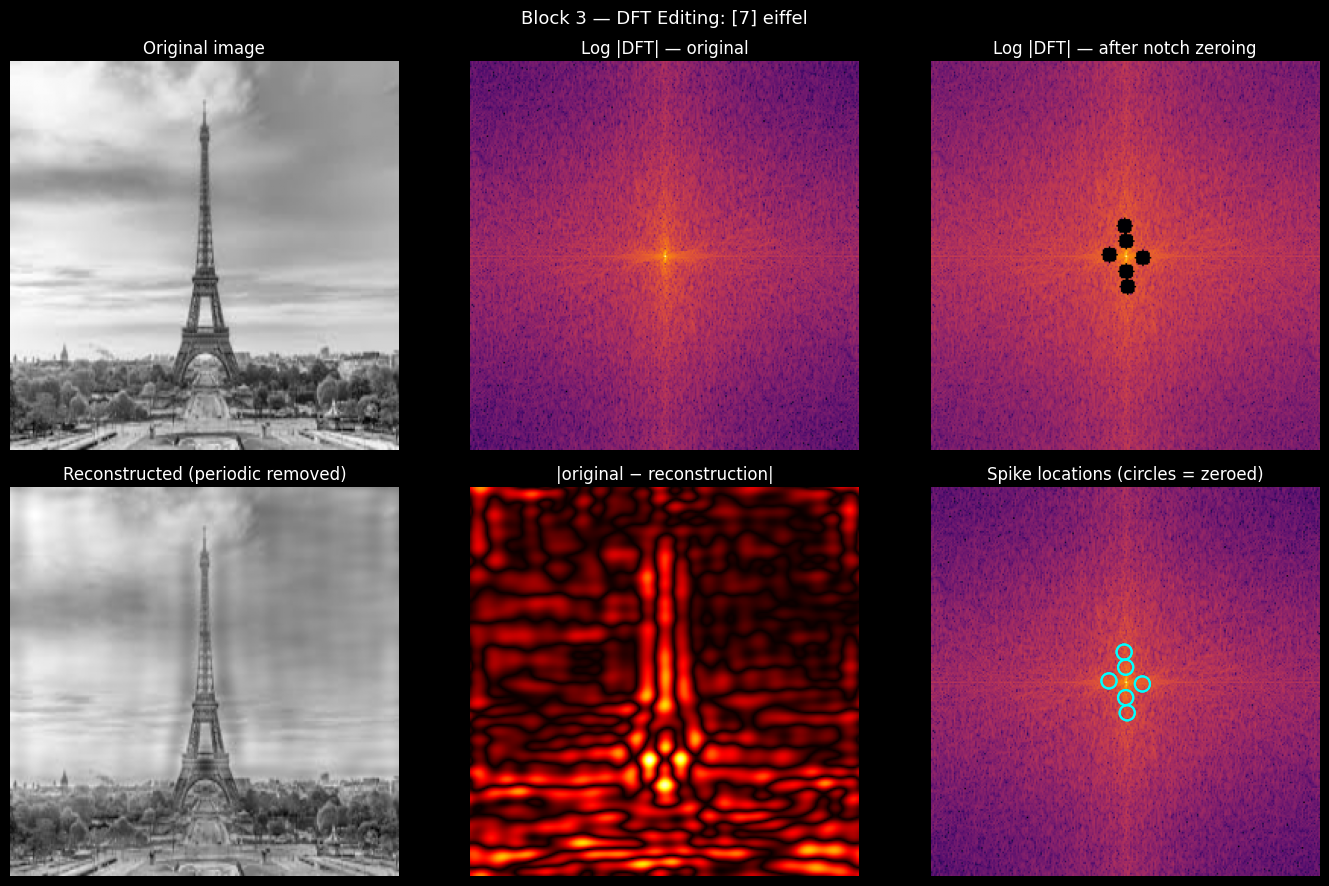

RMSE (original vs recon):  14.861
Mean |diff|:               11.089
Fraction of F zeroed:      0.74%


In [13]:
recon = idft2(F_edited)

amp_orig   = log_amp(F_work)
amp_edited = log_amp(F_edited)
diff_img   = np.abs(img_work - recon)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle(f"Block 3 — DFT Editing: [{SELECTED_IDX}] {names[SELECTED_IDX]}", fontsize=13)

axes[0, 0].imshow(norm(img_work),   cmap="gray");    axes[0, 0].set_title("Original image")
axes[0, 1].imshow(norm(amp_orig),   cmap="inferno"); axes[0, 1].set_title("Log |DFT| — original")
axes[0, 2].imshow(norm(amp_edited), cmap="inferno"); axes[0, 2].set_title("Log |DFT| — after notch zeroing")

axes[1, 0].imshow(norm(recon),      cmap="gray");    axes[1, 0].set_title("Reconstructed (periodic removed)")
axes[1, 1].imshow(norm(diff_img),   cmap="hot");     axes[1, 1].set_title("|original − reconstruction|")

# Annotate spike positions on the edited amplitude
ax_ann = axes[1, 2]
ax_ann.imshow(norm(amp_orig), cmap="inferno")
ax_ann.set_title("Spike locations (circles = zeroed)")
h, w = F_work.shape
for r, c in spikes:
    r2, c2 = (h - r) % h, (w - c) % w
    for (pr, pc) in [(r, c), (r2, c2)]:
        circ = plt.Circle((pc, pr), NOTCH_RADIUS, color="cyan", fill=False, linewidth=1.5)
        ax_ann.add_patch(circ)

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/block3_result.png", dpi=130, bbox_inches="tight")
plt.show()

# Quantitative check
print(f"RMSE (original vs recon):  {np.sqrt(np.mean((img_work - recon)**2)):.3f}")
print(f"Mean |diff|:               {diff_img.mean():.3f}")
print(f"Fraction of F zeroed:      {(F_edited == 0).mean()*100:.2f}%")

## Interactive: tune spike count and notch radius live

Adjust the sliders and the reconstruction updates instantly.

In [14]:
slider_k = widgets.IntSlider(value=6,  min=1, max=20, step=1,  description="Top-K spikes")
slider_r = widgets.IntSlider(value=5,  min=1, max=20, step=1,  description="Notch radius")
out_live  = widgets.Output()

def update_live(k, r):
    with out_live:
        out_live.clear_output(wait=True)
        spikes_live = find_spikes(F_work, top_k=k)
        F_live = F_work.copy()
        for sp in spikes_live:
            F_live = suppress_notch(F_live, sp, radius=r)
        recon_live = idft2(F_live)

        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].imshow(norm(img_work),   cmap="gray");    axes[0].set_title("Original")
        axes[1].imshow(norm(recon_live), cmap="gray");    axes[1].set_title(f"Reconstructed (k={k}, r={r})")
        axes[2].imshow(norm(np.abs(img_work - recon_live)), cmap="hot"); axes[2].set_title("|diff|")
        for ax in axes: ax.axis("off")
        plt.tight_layout(); plt.show()
        print(f"RMSE={np.sqrt(np.mean((img_work - recon_live)**2)):.2f}  "
              f"fraction zeroed={((F_live==0).mean()*100):.2f}%")

widgets.interact(update_live, k=slider_k, r=slider_r)
display(out_live)

interactive(children=(IntSlider(value=6, description='Top-K spikes', max=20, min=1), IntSlider(value=5, descri…

Output()

---
## Експеримент: видалення Ейфелевої вежі через wedge-маску

Вежа — вертикальна структура. Вертикальні краї у просторі дають **горизонтальну** лінію енергії у ДПФ.
Клиноподібна (wedge) маска обнуляє спайки у трикутній зоні навколо горизонтальної осі спектра.

```
спектр (fftshift, DC у центрі):
     ←  горизонтальна вісь  →
  ●●●●●●●●  DC  ●●●●●●●●    ← енергія від вертикальних структур
```

**Параметри:**
- `WEDGE_HALF_HEIGHT` — півширина клину у пікселях (скільки рядків вище/нижче осі)
- `DC_EXCLUDE` — радіус навколо DC який не чіпаємо
- `FREQ_MIN / FREQ_MAX` — діапазон відстані від DC вздовж горизонтальної осі
- `TOP_K` — скільки найсильніших спайків у wedge зоні обнулити
- `NOTCH_R` — радіус кола навколо кожного спайку

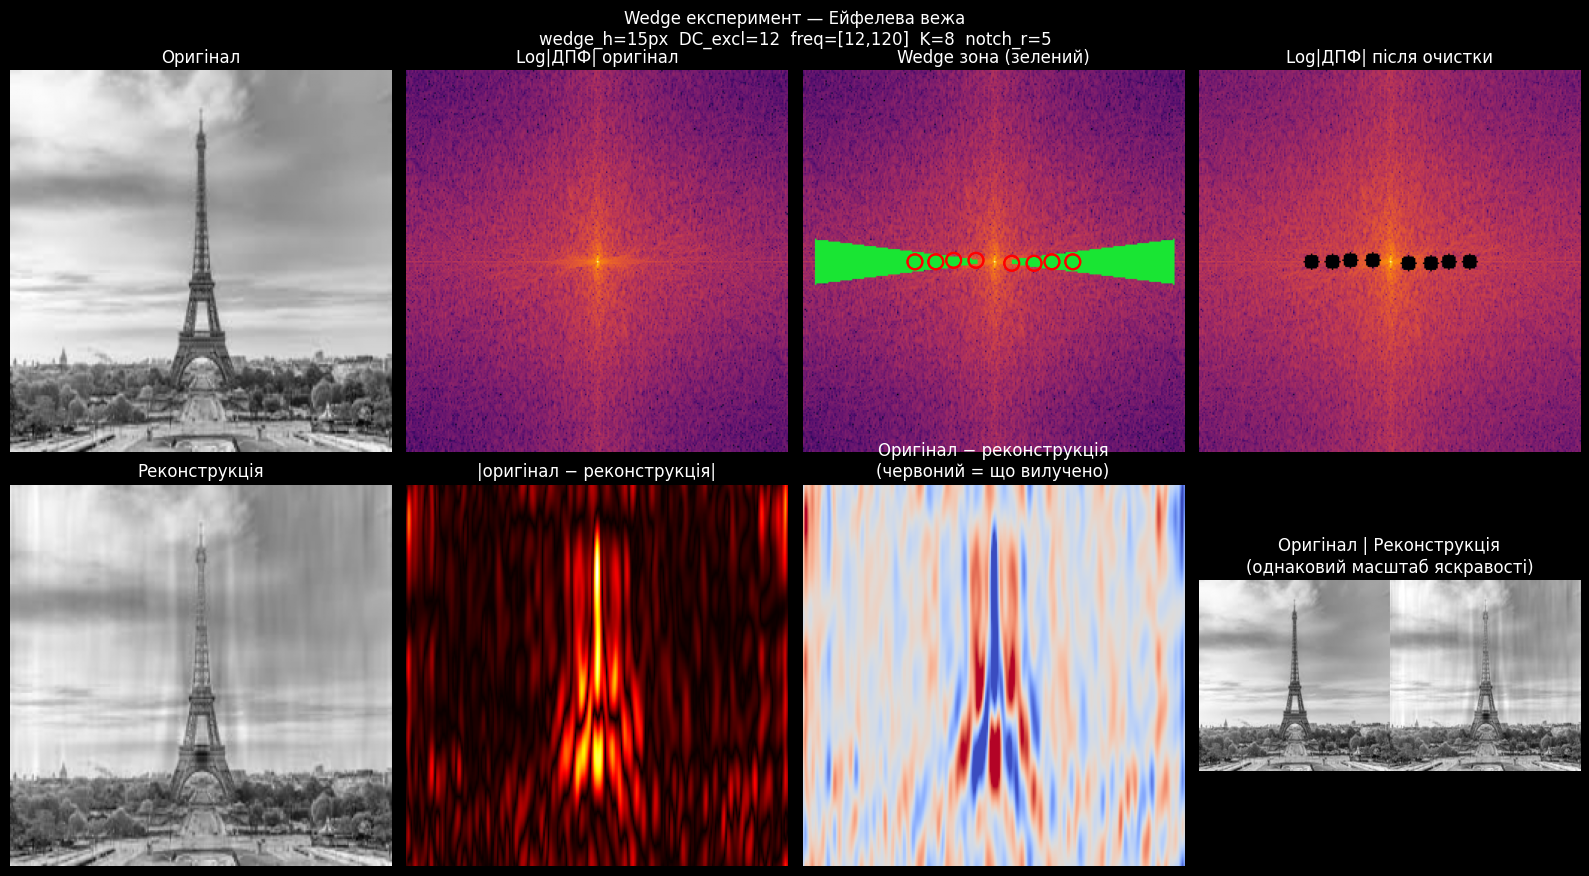

Знайдено спайків:            8 (+ 8 симетричних)
RMSE:                        8.91
Частка спектра у wedge зоні: 5.53%
Спайки (row, col):           [(127, 116), (129, 140), (127, 101), (129, 155), (128, 89), (128, 167), (128, 75), (128, 181)]


In [15]:
import matplotlib.patches as mpatches

# ── Завантажити ейфелеву вежу ─────────────────────────────────────────────
eiffel_idx = names.index("eiffel")
img_e = images[eiffel_idx]
F_e   = dft2(img_e)

# ════════════════════════════════════════════════════════════════════════
# ПАРАМЕТРИ — змінюй і перезапускай клітинку
WEDGE_HALF_HEIGHT = 15   # півширина клину (px вище/нижче горизонтальної осі)
DC_EXCLUDE        = 12   # ігноруємо DC та найнижчі частоти в цьому радіусі
FREQ_MIN          = 12   # мін. відстань від DC по горизонталі (px)
FREQ_MAX          = 120  # макс. відстань від DC по горизонталі (px)
TOP_K             = 8    # кількість спайків для занулення
NOTCH_R           = 5    # радіус notch-кола навколо кожного спайку
# ════════════════════════════════════════════════════════════════════════

h, w = F_e.shape
cy, cx = h // 2, w // 2

# ── Побудувати wedge маску ────────────────────────────────────────────────
# Клин розширюється пропорційно до відстані від DC:
#   dy <= WEDGE_HALF_HEIGHT * (dx / FREQ_MAX)
y_idx, x_idx = np.ogrid[:h, :w]
dx = np.abs(x_idx - cx).astype(np.float32)
dy = np.abs(y_idx - cy).astype(np.float32)
r  = np.hypot(x_idx - cx, y_idx - cy)

wedge = (
    (dy <= WEDGE_HALF_HEIGHT * (dx / max(FREQ_MAX, 1))) &
    (dx >= FREQ_MIN) &
    (dx <= FREQ_MAX) &
    (r  >= DC_EXCLUDE)
).astype(np.float32)

# ── Знайти топ-K спайків всередині wedge ─────────────────────────────────
amp_search = np.abs(F_e).copy()
amp_search[wedge == 0] = 0   # шукаємо тільки всередині клину

spikes_e = []
for _ in range(TOP_K):
    idx = np.argmax(amp_search)
    r_s, c_s = divmod(int(idx), w)
    spikes_e.append((r_s, c_s))
    amp_search[max(0, r_s - NOTCH_R*2):r_s + NOTCH_R*2 + 1,
               max(0, c_s - NOTCH_R*2):c_s + NOTCH_R*2 + 1] = 0

# ── Застосувати notch + симетричний партнер ───────────────────────────────
F_clean = F_e.copy()
y2, x2 = np.ogrid[:h, :w]
for r_s, c_s in spikes_e:
    r2, c2 = (h - r_s) % h, (w - c_s) % w
    for pr, pc in [(r_s, c_s), (r2, c2)]:
        F_clean[(y2 - pr)**2 + (x2 - pc)**2 <= NOTCH_R**2] = 0

recon_e = idft2(F_clean)

# ── Візуалізація ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
fig.suptitle(
    f"Wedge експеримент — Ейфелева вежа\n"
    f"wedge_h={WEDGE_HALF_HEIGHT}px  DC_excl={DC_EXCLUDE}  "
    f"freq=[{FREQ_MIN},{FREQ_MAX}]  K={TOP_K}  notch_r={NOTCH_R}",
    fontsize=12
)

axes[0,0].imshow(norm(img_e), cmap="gray")
axes[0,0].set_title("Оригінал")

axes[0,1].imshow(norm(log_amp(F_e)), cmap="inferno")
axes[0,1].set_title("Log|ДПФ| оригінал")

# Wedge зона підсвічена зеленим поверх амплітуди
amp_rgb = plt.cm.inferno(norm(log_amp(F_e)))[:, :, :3]
wedge_overlay = amp_rgb.copy()
wedge_overlay[wedge == 1] = [0.1, 0.9, 0.2]
axes[0,2].imshow(wedge_overlay)
axes[0,2].set_title("Wedge зона (зелений)")
for r_s, c_s in spikes_e:
    r2, c2 = (h - r_s) % h, (w - c_s) % w
    for pr, pc in [(r_s, c_s), (r2, c2)]:
        axes[0,2].add_patch(plt.Circle((pc, pr), NOTCH_R, color="red", fill=False, lw=1.5))

axes[0,3].imshow(norm(log_amp(F_clean)), cmap="inferno")
axes[0,3].set_title("Log|ДПФ| після очистки")

axes[1,0].imshow(norm(recon_e), cmap="gray")
axes[1,0].set_title("Реконструкція")

axes[1,1].imshow(norm(np.abs(img_e - recon_e)), cmap="hot")
axes[1,1].set_title("|оригінал − реконструкція|")

p98 = np.percentile(np.abs(img_e - recon_e), 98)
axes[1,2].imshow(img_e - recon_e, cmap="coolwarm", vmin=-p98, vmax=p98)
axes[1,2].set_title("Оригінал − реконструкція\n(червоний = що вилучено)")

vmin, vmax = img_e.min(), img_e.max()
axes[1,3].imshow(np.hstack([img_e, recon_e]), cmap="gray", vmin=vmin, vmax=vmax)
axes[1,3].set_title("Оригінал | Реконструкція\n(однаковий масштаб яскравості)")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/eiffel_wedge_experiment.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Знайдено спайків:            {len(spikes_e)} (+ {len(spikes_e)} симетричних)")
print(f"RMSE:                        {np.sqrt(np.mean((img_e - recon_e)**2)):.2f}")
print(f"Частка спектра у wedge зоні: {wedge.mean()*100:.2f}%")
print(f"Спайки (row, col):           {spikes_e}")

In [20]:
# ── Інтерактивні слайдери для wedge експерименту ─────────────────────────────
eiffel_idx = names.index("eiffel")
img_e = images[eiffel_idx]
F_e   = dft2(img_e)
h, w  = F_e.shape
cy, cx = h // 2, w // 2
y2, x2 = np.ogrid[:h, :w]

# Геометрія клину:
#
#         THROAT
#       |←──→|
#   DC  |    |\
#   ●───+    | \  EDGE
#       |    | /
#   ●───+    |/
#       |←──→|←────────→|
#     DC_EXCL   FREQ_MAX
#
# Формула: dy ≤ THROAT + (EDGE - THROAT) * (dx / FREQ_MAX)

s_fmax   = widgets.IntSlider(value=80,  min=10,  max=128, step=2,  description="freq_max",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))
s_dc     = widgets.IntSlider(value=8,   min=1,   max=40,  step=1,  description="DC_excl",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))
s_throat = widgets.IntSlider(value=20,  min=0,   max=80,  step=1,  description="throat (px)",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))
s_edge   = widgets.IntSlider(value=40,  min=0,   max=100, step=1,  description="edge (px)",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))
s_k      = widgets.IntSlider(value=10,  min=1,   max=40,  step=1,  description="top_K",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))
s_nr     = widgets.IntSlider(value=5,   min=1,   max=20,  step=1,  description="notch_r",
                              style={"description_width":"80px"}, layout=widgets.Layout(width="380px"))

controls = widgets.VBox([
    widgets.HTML("<b>Геометрія клину</b>"),
    widgets.HBox([s_fmax,   s_dc]),
    widgets.HBox([s_throat, s_edge]),
    widgets.HTML("<b>Пошук спайків</b>"),
    widgets.HBox([s_k,      s_nr]),
])
out_w = widgets.Output()

def run_wedge(freq_max, dc_excl, throat, edge, top_k, notch_r):
    with out_w:
        out_w.clear_output(wait=True)

        y_idx, x_idx = np.ogrid[:h, :w]
        dx = np.abs(x_idx - cx).astype(np.float32)
        dy = np.abs(y_idx - cy).astype(np.float32)
        r  = np.hypot(x_idx - cx, y_idx - cy)

        # Ширина клину лінійно інтерполюється між throat (біля DC) і edge (на кінці)
        wedge_width = throat + (edge - throat) * (dx / max(freq_max, 1))
        wedge = (
            (dy <= wedge_width) &
            (dx <= freq_max) &
            (r  >= dc_excl)
        ).astype(np.float32)

        # Знайти спайки всередині wedge
        amp_search = np.abs(F_e).copy()
        amp_search[wedge == 0] = 0
        spikes_e = []
        for _ in range(top_k):
            idx = np.argmax(amp_search)
            r_s, c_s = divmod(int(idx), w)
            spikes_e.append((r_s, c_s))
            amp_search[max(0, r_s - notch_r*2):r_s + notch_r*2 + 1,
                       max(0, c_s - notch_r*2):c_s + notch_r*2 + 1] = 0

        # Застосувати notch + симетричний партнер
        F_clean = F_e.copy()
        for r_s, c_s in spikes_e:
            r2, c2 = (h - r_s) % h, (w - c_s) % w
            for pr, pc in [(r_s, c_s), (r2, c2)]:
                F_clean[(y2 - pr)**2 + (x2 - pc)**2 <= notch_r**2] = 0
        recon_e = idft2(F_clean)

        fig, axes = plt.subplots(2, 4, figsize=(16, 9))
        fig.suptitle(
            f"freq_max={freq_max}  DC_excl={dc_excl}  "
            f"throat={throat}  edge={edge}  K={top_k}  notch_r={notch_r}",
            fontsize=11
        )
        axes[0,0].imshow(norm(img_e), cmap="gray");             axes[0,0].set_title("Оригінал")
        axes[0,1].imshow(norm(log_amp(F_e)), cmap="inferno");   axes[0,1].set_title("Log|ДПФ|")

        amp_rgb = plt.cm.inferno(norm(log_amp(F_e)))[:,:,:3]
        wedge_overlay = amp_rgb.copy()
        wedge_overlay[wedge == 1] = [0.1, 0.9, 0.2]
        axes[0,2].imshow(wedge_overlay);                        axes[0,2].set_title("Wedge зона (зелений)")
        for r_s, c_s in spikes_e:
            r2, c2 = (h - r_s) % h, (w - c_s) % w
            for pr, pc in [(r_s, c_s), (r2, c2)]:
                axes[0,2].add_patch(plt.Circle((pc, pr), notch_r, color="red", fill=False, lw=1.5))

        axes[0,3].imshow(norm(log_amp(F_clean)), cmap="inferno"); axes[0,3].set_title("Log|ДПФ| після")
        axes[1,0].imshow(norm(recon_e), cmap="gray");            axes[1,0].set_title("Реконструкція")
        axes[1,1].imshow(norm(np.abs(img_e - recon_e)), cmap="hot"); axes[1,1].set_title("|diff|")

        p98 = np.percentile(np.abs(img_e - recon_e), 98)
        axes[1,2].imshow(img_e - recon_e, cmap="coolwarm", vmin=-p98, vmax=p98)
        axes[1,2].set_title("що вилучено (червоний)")

        vmin, vmax = img_e.min(), img_e.max()
        axes[1,3].imshow(np.hstack([img_e, recon_e]), cmap="gray", vmin=vmin, vmax=vmax)
        axes[1,3].set_title("до | після")

        for ax in axes.flat: ax.axis("off")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/eiffel_wedge_experiment.png", dpi=130, bbox_inches="tight")
        plt.show()
        print(f"RMSE={np.sqrt(np.mean((img_e - recon_e)**2)):.2f}  "
              f"wedge покриття={wedge.mean()*100:.2f}%  спайки={spikes_e}")

display(controls, out_w)
widgets.interact(run_wedge,
    freq_max=s_fmax, dc_excl=s_dc,
    throat=s_throat, edge=s_edge,
    top_k=s_k, notch_r=s_nr)

Output()

interactive(children=(IntSlider(value=80, description='freq_max', layout=Layout(width='380px'), max=128, min=1…

<function __main__.run_wedge(freq_max, dc_excl, throat, edge, top_k, notch_r)>

---
## Експеримент: Minecraft — видалення горизонтальних структур (шрифт, горизонт, блоки)

Minecraft містить **регулярну блокову структуру** і горизонтальний шрифт — вони дають чіткі спайки
вздовж **вертикальної осі** спектра (перпендикулярно до горизонтальних країв).

```
спектр (fftshift, DC у центрі):

        ↑  вертикальна вісь
        ●   ← енергія від горизонтальних структур
        ●
   DC ──●──
        ●
        ●
```

Клин тепер орієнтований **вертикально** — `dx` і `dy` помінялись місцями відносно ейфельського експерименту.

In [19]:
# ── Завантажити майнкрафт ─────────────────────────────────────────────────────
mc_idx = names.index("minecraft")
img_mc = images[mc_idx]
F_mc   = dft2(img_mc)
h, w   = F_mc.shape
cy, cx = h // 2, w // 2
y2, x2 = np.ogrid[:h, :w]

#
#  Геометрія вертикального клину (для горизонтальних структур):
#
#         ┌──── throat ────┐
#    DC ──┤                ├── edge
#         └────────────────┘
#         ↑                ↑
#      DC_excl          freq_max  (по вертикальній осі)
#
# Формула: dx ≤ throat + (edge - throat) * (dy / freq_max)

s_fmax   = widgets.IntSlider(value=60,  min=10,  max=128, step=2,  description="freq_max",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))
s_dc     = widgets.IntSlider(value=8,   min=1,   max=40,  step=1,  description="DC_excl",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))
s_throat = widgets.IntSlider(value=15,  min=0,   max=80,  step=1,  description="throat (px)",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))
s_edge   = widgets.IntSlider(value=5,   min=0,   max=80,  step=1,  description="edge (px)",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))
s_k      = widgets.IntSlider(value=12,  min=1,   max=50,  step=1,  description="top_K",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))
s_nr     = widgets.IntSlider(value=5,   min=1,   max=20,  step=1,  description="notch_r",
                              style={"description_width":"90px"}, layout=widgets.Layout(width="400px"))

controls_mc = widgets.VBox([
    widgets.HTML("<b>Геометрія вертикального клину</b>"),
    widgets.HBox([s_fmax,   s_dc]),
    widgets.HBox([s_throat, s_edge]),
    widgets.HTML("<b>Пошук спайків</b>"),
    widgets.HBox([s_k,      s_nr]),
])
out_mc = widgets.Output()

def run_mc(freq_max, dc_excl, throat, edge, top_k, notch_r):
    with out_mc:
        out_mc.clear_output(wait=True)

        y_idx, x_idx = np.ogrid[:h, :w]
        dx = np.abs(x_idx - cx).astype(np.float32)   # горизонтальне відхилення
        dy = np.abs(y_idx - cy).astype(np.float32)   # вертикальне відхилення
        r  = np.hypot(x_idx - cx, y_idx - cy)

        # Вертикальний клин: обмежуємо dx залежно від dy
        wedge_width = throat + (edge - throat) * (dy / max(freq_max, 1))
        wedge = (
            (dx <= wedge_width) &
            (dy <= freq_max) &
            (r  >= dc_excl)
        ).astype(np.float32)

        # Знайти топ-K спайків всередині wedge
        amp_search = np.abs(F_mc).copy()
        amp_search[wedge == 0] = 0
        spikes_mc = []
        for _ in range(top_k):
            idx = np.argmax(amp_search)
            r_s, c_s = divmod(int(idx), w)
            spikes_mc.append((r_s, c_s))
            amp_search[max(0, r_s - notch_r*2):r_s + notch_r*2 + 1,
                       max(0, c_s - notch_r*2):c_s + notch_r*2 + 1] = 0

        # Застосувати notch + симетричний партнер
        F_clean = F_mc.copy()
        for r_s, c_s in spikes_mc:
            r2, c2 = (h - r_s) % h, (w - c_s) % w
            for pr, pc in [(r_s, c_s), (r2, c2)]:
                F_clean[(y2 - pr)**2 + (x2 - pc)**2 <= notch_r**2] = 0
        recon_mc = idft2(F_clean)

        # Візуалізація
        fig, axes = plt.subplots(2, 4, figsize=(16, 9))
        fig.suptitle(
            f"Minecraft wedge (вертикальний)\n"
            f"freq_max={freq_max}  DC_excl={dc_excl}  "
            f"throat={throat}  edge={edge}  K={top_k}  notch_r={notch_r}",
            fontsize=11
        )

        axes[0,0].imshow(norm(img_mc), cmap="gray");            axes[0,0].set_title("Оригінал")
        axes[0,1].imshow(norm(log_amp(F_mc)), cmap="inferno");  axes[0,1].set_title("Log|ДПФ|")

        amp_rgb = plt.cm.inferno(norm(log_amp(F_mc)))[:,:,:3]
        wedge_overlay = amp_rgb.copy()
        wedge_overlay[wedge == 1] = [0.1, 0.9, 0.2]
        axes[0,2].imshow(wedge_overlay);                        axes[0,2].set_title("Wedge зона (зелений)")
        for r_s, c_s in spikes_mc:
            r2, c2 = (h - r_s) % h, (w - c_s) % w
            for pr, pc in [(r_s, c_s), (r2, c2)]:
                axes[0,2].add_patch(plt.Circle((pc, pr), notch_r, color="red", fill=False, lw=1.5))

        axes[0,3].imshow(norm(log_amp(F_clean)), cmap="inferno"); axes[0,3].set_title("Log|ДПФ| після")
        axes[1,0].imshow(norm(recon_mc), cmap="gray");           axes[1,0].set_title("Реконструкція")
        axes[1,1].imshow(norm(np.abs(img_mc - recon_mc)), cmap="hot"); axes[1,1].set_title("|diff|")

        p98 = np.percentile(np.abs(img_mc - recon_mc), 98)
        axes[1,2].imshow(img_mc - recon_mc, cmap="coolwarm", vmin=-p98, vmax=p98)
        axes[1,2].set_title("що вилучено (червоний)")

        vmin, vmax = img_mc.min(), img_mc.max()
        axes[1,3].imshow(np.hstack([img_mc, recon_mc]), cmap="gray", vmin=vmin, vmax=vmax)
        axes[1,3].set_title("до | після")

        for ax in axes.flat: ax.axis("off")
        plt.tight_layout()
        plt.savefig(f"{OUT_DIR}/minecraft_wedge_experiment.png", dpi=130, bbox_inches="tight")
        plt.show()
        print(f"RMSE={np.sqrt(np.mean((img_mc - recon_mc)**2)):.2f}  "
              f"wedge={wedge.mean()*100:.2f}%  спайки={spikes_mc}")

display(controls_mc, out_mc)
widgets.interact(run_mc,
    freq_max=s_fmax, dc_excl=s_dc,
    throat=s_throat, edge=s_edge,
    top_k=s_k, notch_r=s_nr)

Output()

interactive(children=(IntSlider(value=60, description='freq_max', layout=Layout(width='400px'), max=128, min=1…

<function __main__.run_mc(freq_max, dc_excl, throat, edge, top_k, notch_r)>